# Homework 2 — Linear Algebra for Machine Learning

## Due on 9/8

### Introduction
The goal of this homework is to practice the linear algebra operations in machine learning.



In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create and Inspect the Engineering Data

Suppose vibration, temperature, rotational speed, and pressure are measured from a rotating machine under several operating conditions.

The data matrix is organized as

**row = one operating condition**

**column = one measured feature**

The four columns are:

| Column | Feature |
|---|---|
| 0 | Temperature (°C) |
| 1 | Pressure (kPa) |
| 2 | Speed (rpm) |
| 3 | Vibration (mm/s) |

The data are created for you in the next cell.

**Sanity check:** The shape of `X` should be `(10, 4)`.


In [20]:
# Engineering sensor data
X = np.array(
    [
        [72, 205, 1200, 0.31],
        [75, 210, 1280, 0.35],
        [78, 214, 1350, 0.39],
        [81, 218, 1420, 0.44],
        [84, 221, 1490, 0.49],
        [87, 225, 1560, 0.55],
        [90, 229, 1630, 0.62],
        [93, 233, 1700, 0.69],
        [96, 237, 1770, 0.77],
        [99, 241, 1840, 0.86],
    ],
    dtype=float,
)

feature_names = ["Temperature", "Pressure", "Speed", "Vibration"]

df = pd.DataFrame(X, columns=feature_names)
display(df)

print("Shape:", X.shape)

,Temperature,Pressure,Speed,Vibration
0,72.0,205.0,1200.0,0.31
1,75.0,210.0,1280.0,0.35
2,78.0,214.0,1350.0,0.39
3,81.0,218.0,1420.0,0.44
4,84.0,221.0,1490.0,0.49
5,87.0,225.0,1560.0,0.55
6,90.0,229.0,1630.0,0.62
7,93.0,233.0,1700.0,0.69
8,96.0,237.0,1770.0,0.77
9,99.0,241.0,1840.0,0.86


Shape: (10, 4)


### Matrix Shape and Indexing

Before performing matrix operations, it is important to understand what the entries of the matrix represent.

1. Store the number of operating conditions in `n_samples`.
2. Store the number of measured features in `n_features`.
3. Extract the **speed column** into the variable `speed`.
4. Extract the complete **4th operating condition** into `condition_4`.

Remember that Python counts from 0.



In [21]:
n_samples = df.shape[0]
n_features = df.shape[1]

speed = df["Speed"].values  # Extract speed column as NumPy array
condition_4 = df.iloc[3]  # Index search needs iloc (integer lotation based indexing)

print("Number of samples:", n_samples)
print("Number of features:", n_features)
print("Speed shape:", speed.shape)
print("4th operating condition:", condition_4)

Number of samples: 10
Number of features: 4
Speed shape: (10,)
4th operating condition: Temperature      81.00
Pressure        218.00
Speed          1420.00
Vibration         0.44
Name: 3, dtype: float64


# Matrix Multiplication

A simple machine-learning model often forms a prediction using a weighted sum of input features.

For three features,

$\hat{y} = X\beta$

where:

- \(X\) is the data matrix,
- $(\beta)$ contains model weights,
- $(\hat{y})$ contains the predicted values.

For this question, use the first three columns of `X` as the input matrix `X_input`. A set of model weights has already been provided.

Use **matrix multiplication** to calculate the prediction for all 10 operating conditions at once.




In [22]:
beta = np.array([0.010, 0.002, 0.00025])

X_input = df.iloc[:, 0:3]
y_pred = np.dot(X_input, beta)

print("X_input shape:", X_input.shape)
print("beta shape:", beta.shape)
print("Prediction shape:", y_pred.shape)
print("Predicted values:")
print(y_pred)

X_input shape: (10, 3)
beta shape: (3,)
Prediction shape: (10,)
Predicted values:
[1.43   1.49   1.5455 1.601  1.6545 1.71   1.7655 1.821  1.8765 1.932 ]


### Matrix Multiplication vs. Hadamard Product

Matrix multiplication and element-by-element multiplication are **not the same operation**.

For the small matrices below, calculate:

1. `C_matrix` using matrix multiplication.
2. `C_hadamard` using the Hadamard (element-wise) product.

Then compare the two results.



In [23]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[2, 1], [0, 3]])

C_matrix = np.dot(A, B)
C_hadamard = np.multiply(A, B)

print("Matrix multiplication:")
print(C_matrix)

print("Hadamard product:")
print(C_hadamard)

Matrix multiplication:
[[ 2  7]
 [ 6 15]]
Hadamard product:
[[ 2  2]
 [ 0 12]]


# Broadcasting and Mean Centering

In machine learning, it is common to center each feature by subtracting its mean:

$
X_c = X - \mu
$

where $(\mu)$ is a vector containing the mean of each column.

NumPy broadcasting allows the 1-D mean vector to be subtracted from every row of the data matrix without writing a loop.

Use the first three columns of `X` (temperature, pressure, and speed).

1. Compute the mean of each feature and save it as `feature_mean`.
2. Mean-center the data and save the result as `X_centered`.




In [24]:
feature_mean = np.mean(df.iloc[:, 0:3], axis=0)  # axis=0 means average over columns

# Every row of the data is subtracted by the mean of its column
X_centered = df.iloc[:, 0:3] - feature_mean

print("Feature mean:\n", feature_mean)
print("Centered data shape:", X_centered.shape)

# there is actually some floating point error, so the mean is not exactly zero
print("Mean after centering:\n", X_centered.mean(axis=0))

Feature mean:
 Temperature      85.5
Pressure        223.3
Speed          1524.0
dtype: float64
Centered data shape: (10, 3)
Mean after centering:
 Temperature    0.000000e+00
Pressure      -1.136868e-14
Speed          0.000000e+00
dtype: float64


# Norms as Distance Measures

Norms are commonly used in machine learning to measure **distance** between observations.

To make the units comparable, the next cell creates a standardized version of the first three features. Do not change that cell.

Then compute the Euclidean distance between:

- operating condition 0 and operating condition 1,
- operating condition 0 and operating condition 9.

Use `np.linalg.norm`.





In [25]:
# Standardize the first three features so one unit does not dominate the distance.
X_std = (X_input - X_input.mean(axis=0)) / X_input.std(axis=0)

print("Standardized data shape:", X_std.shape)

Standardized data shape: (10, 3)


In [26]:
X_std_01 = X_std.iloc[0] - X_std.iloc[1]  # subtract rows 0 and 1
X_std_09 = X_std.iloc[0] - X_std.iloc[9]  # subtract rows 0 and 9
d_01 = np.linalg.norm(X_std_01, ord=2, axis=None)  # linalg ord=2 is the Euclidean distance
d_09 = np.linalg.norm(X_std_09, ord=2, axis=None)

print("Distance between conditions 0 and 1:", d_01)
print("Distance between conditions 0 and 9:", d_09)

Distance between conditions 0 and 1: 0.6539373536109212
Distance between conditions 0 and 9: 5.201471897999257


# Linear Regression as a Matrix Problem

Now we will use linear algebra to fit a simple model.

Suppose we want to predict **vibration** from temperature and speed:

$
\hat{y} = \beta_0 + \beta_1(\text{Temperature}) + \beta_2(\text{Speed})
$

This can be written as

$
\hat{y}=X_{\text{reg}}\beta
$

where the first column of $X_{\text{reg}}$ is all ones so that the model can learn the intercept $\beta_0$.

For this homework, compute the model coefficients using the Moore-Penrose pseudoinverse:

$
\beta = X_{\text{reg}}^{+} y
$

Then calculate the predicted vibration values and the residual vector.

Finally, calculate the **L2 norm of the residual vector**.


X_reg shape: (10, 3)
Estimated coefficients: [-3.814       0.14755556 -0.00541667]
Residual norm: 0.058864250611045735


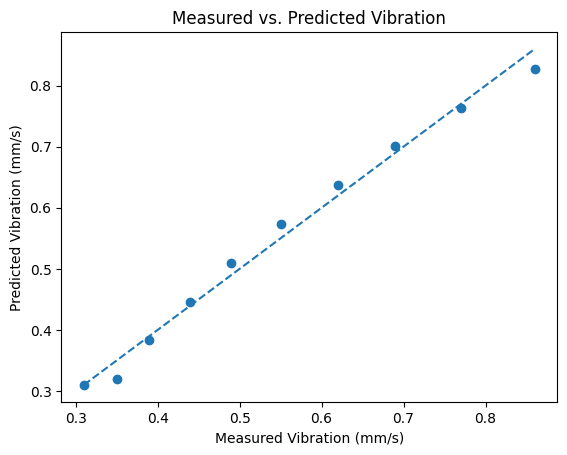

In [27]:
temperature = X[:, 0]
speed = X[:, 2]
y = X[:, 3]  # vibration is the target variable

# Construct the design matrix with an intercept column.
# Matrix of all ones, then temperature, then speed.
X_reg = np.column_stack([np.ones(len(X)), temperature, speed])  # Nx3

# X_+_reg becomes 3xN and y is (N,) so beta_hat is (3,)
beta_hat = np.linalg.pinv(X_reg) @ y  # pinv is the pseudo-inverse; @ y is matrix multiplication

# Predicted values: (N x 3) @ (3 x 1) -> (N x 1)
y_hat = X_reg @ beta_hat  # beta_0 (intercept), beta_1 (temperature), beta_2 (speed) weights

residual = y_hat - y  # difference between actual and predicted values
residual_norm = np.linalg.norm(residual, ord=2, axis=None)

print("X_reg shape:", X_reg.shape)
print("Estimated coefficients:", beta_hat)
print("Residual norm:", residual_norm)

plt.scatter(y, y_hat)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "--")
plt.xlabel("Measured Vibration (mm/s)")
plt.ylabel("Predicted Vibration (mm/s)")
plt.title("Measured vs. Predicted Vibration")
plt.show()

# Eigenvalues and Eigenvectors in Mechanics

Eigenvalues and eigenvectors appear naturally in mechanical engineering.

For a symmetric stress tensor,

$
A v = \lambda v
$

the eigenvalues are the **principal stresses**, and the corresponding eigenvectors give the **principal directions**.

The 2-D stress tensor below is symmetric:


$\sigma =
\begin{bmatrix}
80 & 30\\
30 & 40
\end{bmatrix}
\text{ MPa}
$

Use `np.linalg.eigh` to compute the eigenvalues and eigenvectors.

Then identify:

1. the maximum principal stress,
2. the eigenvector corresponding to that maximum principal stress,
3. whether \(A v= $\lambda$ v\) is satisfied numerically.

**Hint:** `np.linalg.eigh` returns eigenvalues in ascending order.


In [28]:
stress = np.array([[80.0, 30.0], [30.0, 40.0]])
eigenvalues, eigenvectors = np.linalg.eigh(stress)

max_principal_stress = eigenvalues[-1]  # ascending order, so last is biggest
principal_direction = eigenvectors[:, -1]  # direction x, y (2x2) with each col for each eigenvalue
left_side = stress @ eigenvectors  # A is the stress tensor; 2x2 @ 2x2 -> 2x2
# use * (element-wise) to broadcast 1x2 eigenvalues (lambda) across 2x2 eigenvectors (v) -> 2x2
right_side = eigenvalues * eigenvectors

print("Eigenvalues (principal stresses):", eigenvalues)
print("Maximum principal stress:", max_principal_stress)
print("Principal direction:", principal_direction)
print("A @ v =", left_side)
print("lambda * v =", right_side)
print("Verification error:", np.linalg.norm(left_side - right_side))  # floating-point error if any

Eigenvalues (principal stresses): [23.94448725 96.05551275]
Maximum principal stress: 96.05551275463989
Principal direction: [-0.8816746  -0.47185793]
A @ v = [[ 11.29839608 -84.68970567]
 [-21.11124618 -45.32455498]]
lambda * v = [[ 11.29839608 -84.68970567]
 [-21.11124618 -45.32455498]]
Verification error: 7.944109290391274e-15


# Discussion Questions

Answer each question in a few sentences.

1. In the sensor data matrix, what does a **row** represent and what does a **column** represent? Why is this organization useful in machine learning?

2. In Code Question 3, why do matrix multiplication and the Hadamard product give different results even though both use multiplication?

3. After mean centering, why should the mean of each feature be approximately zero? What role does broadcasting play in this operation?

4. The Euclidean distance between condition 0 and condition 1 is much smaller than the distance between condition 0 and condition 9. What does that tell you about these operating conditions?

5. In the regression problem, what does the residual norm measure? Would you prefer a larger or smaller value, and why?

6. For the stress tensor, explain the physical meaning of the largest eigenvalue and its corresponding eigenvector.


### Answers 

1. Each row represents a sample and each column represents a feature. This is great for machine learning as this can become a matrix and multiplying by a matrix of weights works and gets us the target feature predictions -> feature matrix Nx3  @  weight matrix 3x1 -> Nx1 predictions of target. ML algos expect data in the form Observations x Features.

2. Matrix multiplication combines rows from the first matrix with columns from the second using the dot product. Hadamard just multiplies elements in their corresponding posisionts (1x1 and 1x1; 1x2 and 1x2, etc.). So the operations have different rules and thus usually yield different results or even shapes. 

3. Mean centering subtracts the mean value of each feature from every value in that feature. So, it is trivial that, affter centering (subtracting the mean), the new mean will be zero. It is a shift in data toward the center. Broadcasting (*) allows the vector of the column means to be subtracted from every row of the matrix - allows NumPy to treat the column-mean vector as though it were repeated for every row.

4. It tells us that conditions 0 and 1 have more similar sensor measurements than conditions 0 and 9. Condition 9 being farther away in the feature space represents a more different operating condition. This is obviously assuming the features have comparable scales or have been normalized/standardized.

5. The residual norm measures the overall difference between the actual and predicted vibrations. It sums the squares of each residual (expected - actual) and square-roots it. A smaller residual norm is prederred as it means the model's predictions are closer to the observed values - the smaller the residual, the smaller the errors were.

6. Since it is a symmetric stress tensor, the eigenvalues are the principal stresses. The largest is the maximum principal stress and the corresponding eigenvector fives the direction in which that stress acts. This can help identifty the direction most suceptible to deformation or failure, for example.

# Singular Value Decomposition of Stress-Strain Curves

In the original Jupyter homework, the file `Stress_Strain_Curves.npy` contains **10 stress-strain curves**, and each curve is represented by **1456 data points**.

Therefore, the data matrix has the form

$
X \in \mathbb{R}^{10 \times 1456}
$

where:

- each **row** represents one stress-strain curve,
- each **column** represents one measurement location along the curve.

A complete curve therefore requires 1456 values. In this problem, we will use **Singular Value Decomposition (SVD)** to determine whether the curves can be approximately represented using a much smaller number of important patterns.

For a matrix \(X\),

$
X = U\Sigma V^T
$

where:

- U describes how strongly each curve uses each pattern,
- $\Sigma$ contains the singular values,
- $V^T$ contains the patterns across the stress-strain curves.



## Part A — Load and Inspect the Dataset

Load `Stress_Strain_Curves.npy` using `np.load()`.

Then:

1. print the shape of the dataset,
2. plot all 10 stress-strain curves on the same figure.

**Sanity check:** The shape should be `(10, 1456)`.


Dataset shape: (10, 1456)


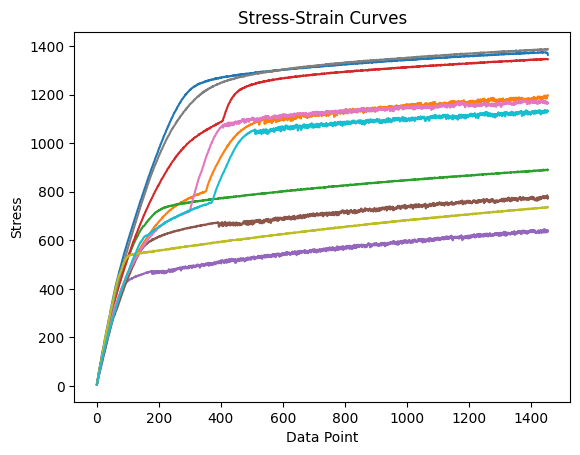

In [29]:
stress_strain_file = "Stress_Strain_Curves.npy"
curves = np.load(stress_strain_file)  # .npy file use numpy

print("Dataset shape:", curves.shape)

plt.figure()
plt.plot(curves.T)
plt.xlabel("Data Point")
plt.ylabel("Stress")
plt.title("Stress-Strain Curves")
plt.show()

## Part B — Perform Singular Value Decomposition

Use NumPy to compute the reduced SVD:

$
X = U\Sigma V^T
$

Use

```python
np.linalg.svd(..., full_matrices=False)
```

and store the results in `U`, `S`, and `Vt`.



In [30]:
# SVD with full_matrices=False limits dimensions to min(m, n) = 10
# U is curves x modes; S is magnitude of each mode; Vt is modes x datapoints
U, S, Vt = np.linalg.svd(curves, full_matrices=False)

print("U shape:", U.shape)  # (10, 10) Sample weights mapping each curve to the 10 shape modes
print("S shape:", S.shape)  # (10,) Singular values quantifying importance of each Vt mode
print("Vt shape:", Vt.shape)  # (10, 1456) 10 fundamental eigen curve profiles

print("\nSingular values:")
print(S)

U shape: (10, 10)
S shape: (10,)
Vt shape: (10, 1456)

Singular values:
[1.16297230e+05 4.84333366e+03 2.86691024e+03 1.20248331e+03
 5.29242970e+02 3.31867344e+02 2.23262798e+02 1.59561741e+02
 1.17634900e+02 8.08584843e+01]


### Short Question

The original matrix contains 1456 columns, but NumPy returns only 10 singular values.

**Why can there be at most 10 nonzero singular values for this dataset?**


### Answer

Because the max amount of non-zero singular values is limited by the matrix rank, and the matrix rank can never exceed the smaller dimension of the dataset.

The dataset being 10x1456, the smaller dimension is 10.

## Part C — Inspect the Singular Values

The singular values indicate the relative importance of the patterns found by SVD.

A **larger singular value** means that its corresponding pattern contributes more strongly to the original dataset.

Create a plot of the 10 singular values.

Use component numbers 1 through 10 on the horizontal axis.


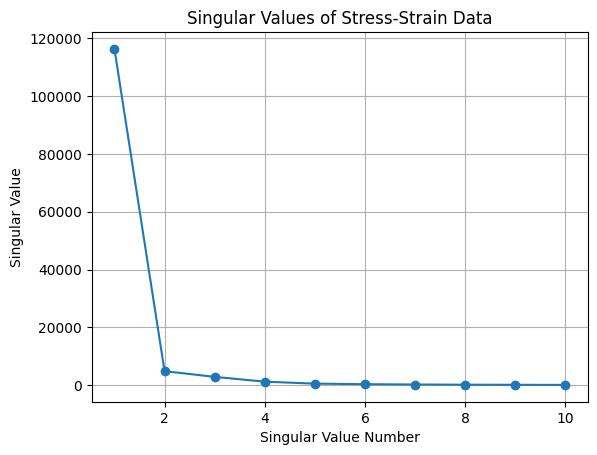

In [31]:
component_number = [i for i in range(1, 11)]

plt.figure()
plt.plot(component_number, S, marker="o")
plt.xlabel("Singular Value Number")
plt.ylabel("Singular Value")
plt.title("Singular Values of Stress-Strain Data")
plt.grid(True)
plt.show()

### Short Question

Compare the first few singular values with the remaining singular values.

**What does the plot suggest about whether all 10 patterns are equally important?**


### Answer

The first singular value being so high and the rest exponentially decaying means that the first singular value accounts for like 99.8% of the dataset's squared magnitude. This means the ten patterns are not equally important, with one dominant pattern providing a strong approximation of the curves - which indicates they are of similar shape.

## Part D — Visualize the First Two Right Singular Vectors

The rows of \(V^T\) describe patterns across the 1456 points of a stress-strain curve.

Plot:

- the first right singular vector, `Vt[0]`,
- the second right singular vector, `Vt[1]`.

These two vectors do not represent individual experimental curves. Instead, they represent two patterns that can be combined to help describe the original curves.


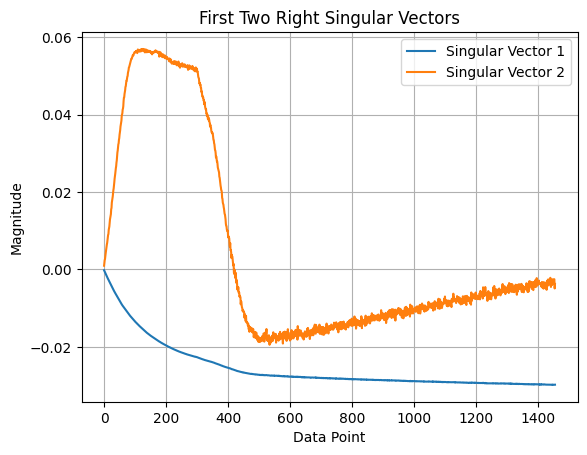

In [32]:
plt.figure()
plt.plot(Vt[0], label="Singular Vector 1")
plt.plot(Vt[1], label="Singular Vector 2")

plt.xlabel("Data Point")
plt.ylabel("Magnitude")
plt.title("First Two Right Singular Vectors")
plt.legend()
plt.grid(True)
plt.show()

### Short Question

Do the first two singular vectors have the same shape?

Briefly explain what it means for SVD to identify different patterns in the stress-strain dataset.


### Answer
No, the first two right singular vectors don't have the same shape. The first represents the dominant shared pattern in the curves and the second represents
the largest other pattern needed to account for differences not captured in the first. Each original curve can be approximated using a differently weighted combination
of these patterns. 

- Vt[0] is monotonic shape going from 0 to around -0.03.
- Vt[1] rises to around 0.055, crosses zero around 420, goes to around -0.02 and then monotonically approaches 0.

This means the first mode mainly captures the common overall shape shared by all ten curves. And, since VT[1] is positive before 420 and negative afterward:
- A positive coefficients for mode 2 raise the early region and lower the later region relative to the rank-1 approximation. Negative has the opposite effect.


## Part E — Low-Rank Reconstruction

SVD can approximate the original data using only the first \(k\) singular values and singular vectors.

The rank k approximation is

$
X_k = U_k \Sigma_k V_k^T
$

Start with

k=1

and reconstruct all 10 stress-strain curves using only the first singular value and its corresponding singular vectors.


In [33]:
k = [i for i in range(1, 11)]
curves_reconstructed: dict[int, np.ndarray] = {}

for i in k:
    S_k = S[:i]  # S is (10,) with each being singular values of  modes; we need first k ranks
    Vt_k = Vt[:i, :]  # rows are SVD modes, columns are data; we need first k modes for all data
    U_k = U[:, :i]  # rows are curves, columns are singular vectors of ranks; need first k vectors

    # S_k is 1D; need to broadcast for matrix multiplication
    X_k = (U_k * S_k) @ Vt_k
    curves_reconstructed[i] = X_k

print("Reconstructed matrix shape:", curves_reconstructed[1].shape)

Reconstructed matrix shape: (10, 1456)


## Part F — Compare an Original Curve with Its Reconstruction

Use curve number 4 as an example.

Plot the original curve and its rank-1 reconstruction on the same figure.

Then change `k` in the previous code cell to:

- `k = 2`
- `k = 3`
- `k = 5`

Rerun the reconstruction and comparison plot each time.

Observe how the reconstruction changes as more singular values are retained.


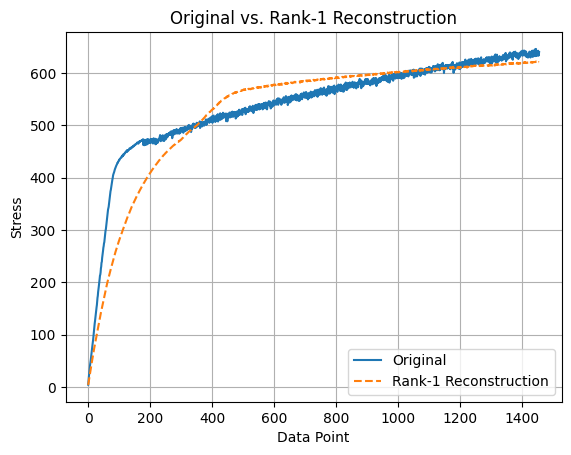

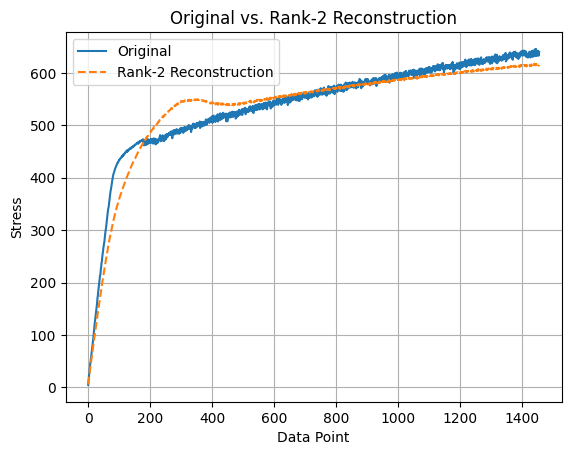

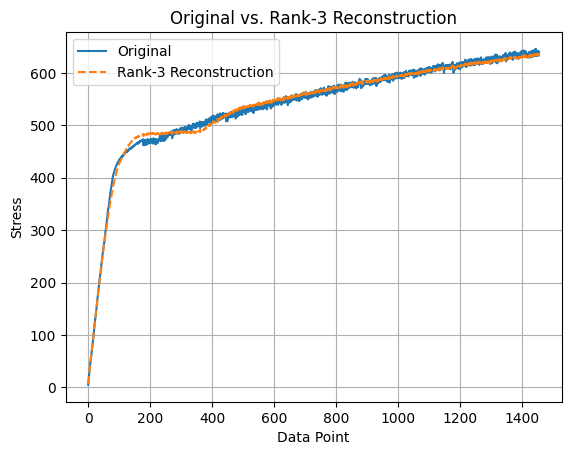

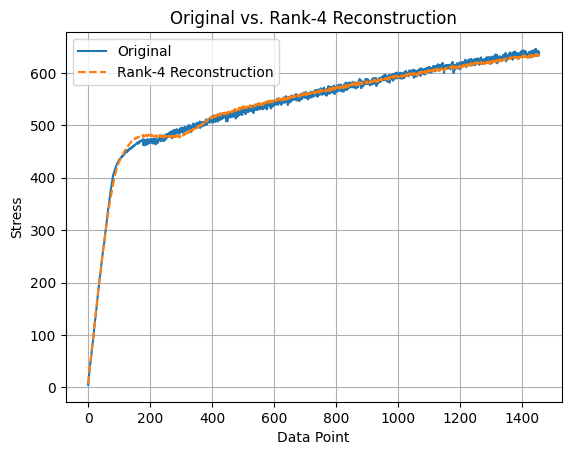

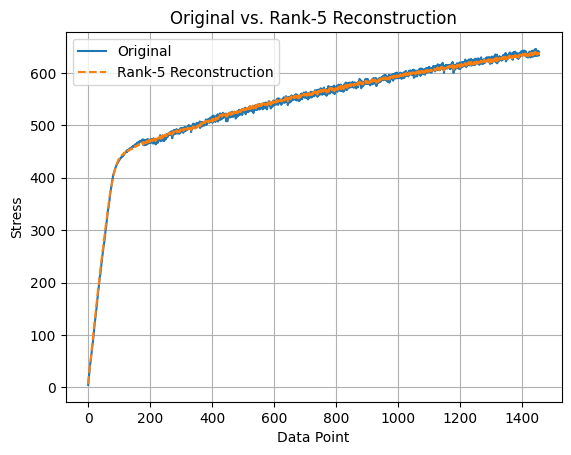

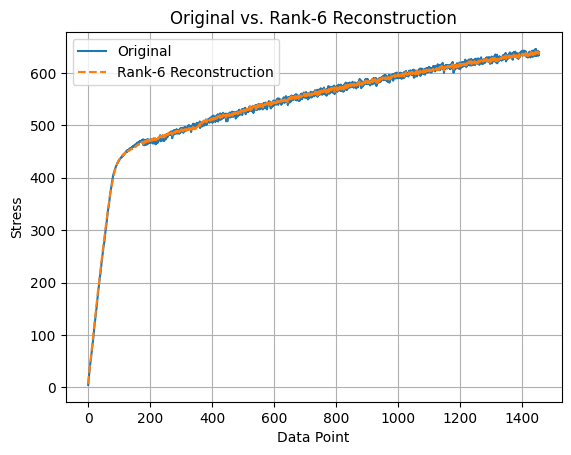

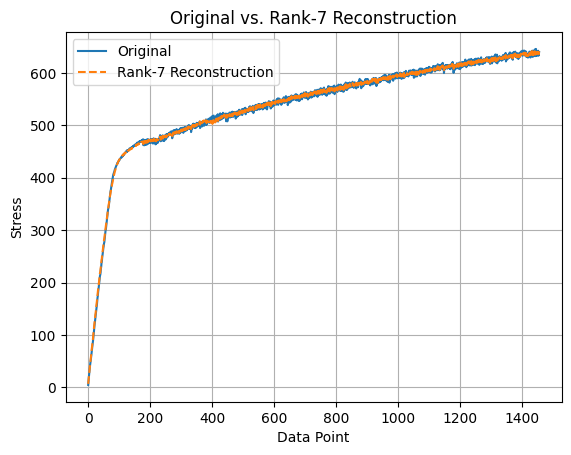

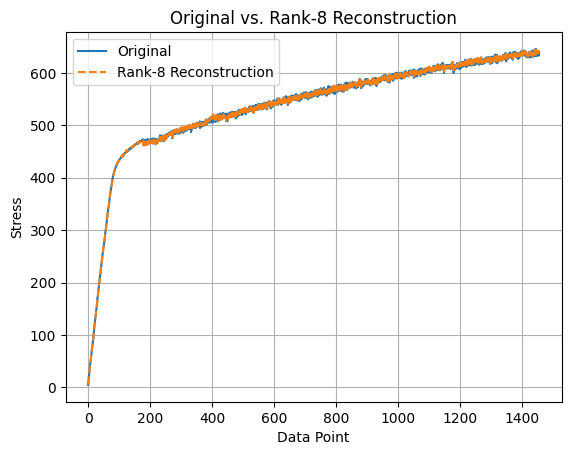

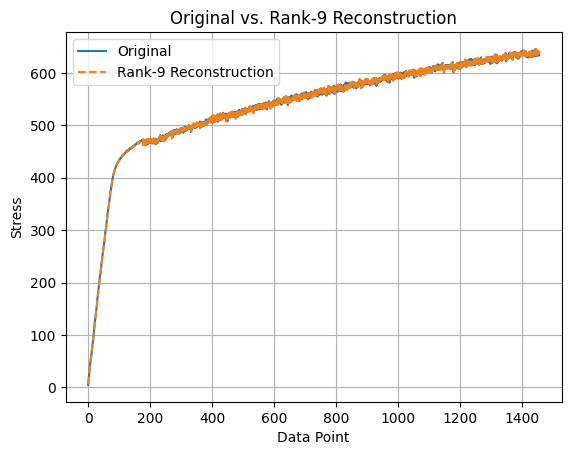

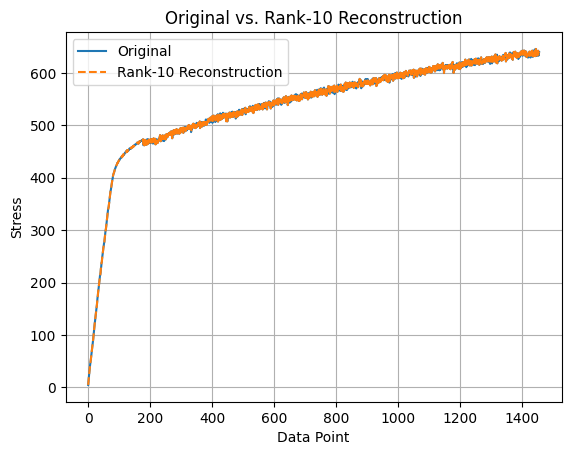

In [34]:
curve_num = 4

for rank, X_k in curves_reconstructed.items():
    plt.figure()

    plt.plot(curves[curve_num], label="Original")
    plt.plot(X_k[curve_num], "--", label=f"Rank-{rank} Reconstruction")

    plt.xlabel("Data Point")
    plt.ylabel("Stress")
    plt.title(f"Original vs. Rank-{rank} Reconstruction")
    plt.legend()
    plt.grid(True)
    plt.show()

## Part G — Measure Reconstruction Error

The Frobenius norm can measure the difference between the original matrix and its approximation:

$
\|X-X_k\|_F
$

Calculate the reconstruction error for the current value of \(k\).

A smaller value means the reconstructed dataset is closer to the original dataset.


In [35]:
for rank, X_k in curves_reconstructed.items():
    error = curves - X_k
    reconstruction_error = np.linalg.norm(error, ord="fro")

    print(f"Rank-{rank} reconstruction error: {reconstruction_error:.4f}")

Rank-1 reconstruction error: 5797.3216
Rank-2 reconstruction error: 3186.0723
Rank-3 reconstruction error: 1389.9217
Rank-4 reconstruction error: 697.0770
Rank-5 reconstruction error: 453.6719
Rank-6 reconstruction error: 309.3255
Rank-7 reconstruction error: 214.0935
Rank-8 reconstruction error: 142.7448
Rank-9 reconstruction error: 80.8585
Rank-10 reconstruction error: 0.0000


## Part H — Compare Different Rank Approximations

The code below repeats the reconstruction for several values of `k`.

Complete the missing expression for the Frobenius norm.

Then observe how the reconstruction error changes as more singular values are retained.


In [36]:
for k_test in [1, 2, 3, 5, 10]:
    U_k = U[:, :k_test]
    S_k = S[:k_test]
    Vt_k = Vt[:k_test, :]

    X_k = U_k @ np.diag(S_k) @ Vt_k

    error = curves - X_k
    reconstruction_error = np.linalg.norm(error, ord="fro")

    print(f"k = {k_test}: reconstruction error = {reconstruction_error:.4f}")

k = 1: reconstruction error = 5797.3216
k = 2: reconstruction error = 3186.0723
k = 3: reconstruction error = 1389.9217
k = 5: reconstruction error = 453.6719
k = 10: reconstruction error = 0.0000


# SVD Discussion Questions

Answer each question in a few sentences.

1. The original stress-strain dataset requires **1456 values to describe each curve**. How can SVD help represent the curves using fewer patterns?

2. Why are there only **10 singular values** even though each curve contains 1456 data points?

3. What happens to the reconstructed stress-strain curve as \(k\) increases from 1 to 5? Why?

4. What happens to the Frobenius reconstruction error as \(k\) increases?

5. If `k = 10` uses all available singular values, what should happen to the reconstruction error? Explain your answer.


### Answers

1. SVD finds shared patterns across all ten curves and instead of describing each curve independently with all having the 1456 values, each curve is approximated as a weighted combination of the first few ranks (k). When using a small number of k, it provides a lower dimensional representation of the data. The reconstructed curve still contains 1,456 points, but those points are generated from a much smaller number of mode coefficients.

2. The number of non-zero singular values cannot exceed the rank of the matrix and the rank cannot exceed the smaller dimension of the matrix. Although each curve has 1,456 values, ten curve vectors can span at most ten independent directions or modes. Therefore, at most ten SVD modes are needed to represent all ten curves exactly, and fewer may provide a useful approximation when the curves are similar.

3. As (k) increases from 1 to 5, the reconstructed curves become progressively closer to the original curves. This happens as each additional mode captures another pattern or detail that the previous modes could not represent.

4. The Frobenius reconstruction error decreases (or, theoretically, never increases) as k increases. This happens because retaining more SVD modes allows the reconstruction to preserve more information from the original dataset.

5. When (k=10), all singular values and vectors are retained, so the reconstructed matrix is exactly equal to the original matrix. Therefore, the reconstruction error is zero. It may be a very small value because of floating-point rounding.
